In [1]:
"""
Module for handling Simple Stellar Population (SSP) data.

This module provides utilities to retrieve and store SSP data using 
FSPS and JAX for efficient operations. It defines a frozen dataclass 
for storing SSP-related data, as well as functions for data collection.

Globals:
--------
DEFAULT_SSP_BNAME : str
    The default file name for the SSP data.
"""

import h5py
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from dataclasses import dataclass
import jax
import jax.numpy as jnp
import tqdm
import blackjax
from functools import partial
from jax import jit, grad

import astropy.constants as const

import matplotlib.pyplot as plt
import fsps


@dataclass(frozen=True)
class SSPData:
    """
    A frozen dataclass to store information about Simple Stellar Population (SSP) templates.

    Attributes:
    -----------
    ssp_lgmet : jnp.ndarray
        1D array of log10(Z) representing the metallicity values of the SSP templates.
        Z is the mass fraction of elements heavier than Helium (He).

    ssp_lg_age_gyr : jnp.ndarray
        1D array of log10(age/Gyr) representing the ages of the SSP templates.

    ssp_wave : jnp.ndarray
        1D array of wavelength values for the SSP spectra.

    ssp_flux : jnp.ndarray
        3D array of shape (n_met, n_ages, n_wave) containing the Spectral Energy 
        Distribution (SED) of the SSP in units of Lsun/Hz. This represents the 
        flux for each combination of metallicity, age, and wavelength.

    ssp_flux_aa : Optional[jnp.ndarray]
        3D array of shape (n_met, n_ages, n_wave) containing the SED of the SSP in
        units of Lsun/AA, but with wavelengths in Angstroms (Å). This is an
        optional attribute that may not be present in all SSP datasets. If not provided,
    """

    ssp_lgmet: jnp.ndarray
    ssp_lg_age_gyr: jnp.ndarray
    ssp_wave: jnp.ndarray
    ssp_flux: jnp.ndarray
    log_qq: jnp.ndarray
    

    def __post_init__(self):
        """Validate the shapes of the SSP data after initialization."""
        if self.ssp_flux.shape != (self.ssp_lgmet.size, self.ssp_lg_age_gyr.size, self.ssp_wave.size):
            raise ValueError(
                f"Shape mismatch: 'ssp_flux' should have shape "
                f"(n_met, n_ages, n_wave), but got {self.ssp_flux.shape}. "
                f"Expected: ({self.ssp_lgmet.size}, {self.ssp_lg_age_gyr.size}, {self.ssp_wave.size})"
            )
    

    def save(self, filename):
        """
        Save the SSPData object to an HDF5 file.

        Parameters:
        -----------
        filename : str
            The file to which the data will be saved.
        """
        with h5py.File(filename, 'w') as f:
            # Save each array as a dataset in the HDF5 file
            f.create_dataset('ssp_lgmet', data=np.array(self.ssp_lgmet))
            f.create_dataset('ssp_lg_age_gyr', data=np.array(self.ssp_lg_age_gyr))
            f.create_dataset('ssp_wave', data=np.array(self.ssp_wave))
            f.create_dataset('ssp_flux', data=np.array(self.ssp_flux))
            f.create_dataset('log_qq', data=np.array(self.log_qq))

    @classmethod
    def load(cls, filename):
        """
        Load the SSPData object from an HDF5 file.

        Parameters:
        -----------
        filename : str
            The file from which the data will be loaded.
        
        Returns:
        --------
        SSPData : SSPData
            An instance of SSPData containing the loaded data.
        """
        with h5py.File(filename, 'r') as f:
            # Load each dataset from the HDF5 file
            ssp_lgmet = jnp.array(f['ssp_lgmet'][:])
            ssp_lg_age_gyr = jnp.array(f['ssp_lg_age_gyr'][:])
            ssp_wave = jnp.array(f['ssp_wave'][:])
            ssp_flux = jnp.array(f['ssp_flux'][:])
            log_qq = jnp.array(f['log_qq'][:])


        return cls(ssp_lgmet, ssp_lg_age_gyr, ssp_wave, ssp_flux, log_qq)


def add_zh(zh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        zh (array-like): The metallicity at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    zh = jnp.array(zh)  # Ensure sfh is a JAX array

    if lookback_time is not None:
        print('lookback time')
        lookback_time = jnp.array(lookback_time)
        zh_times = lookback_time*1e9  
    elif forward_time is not None:
        print('forward time')
        forward_time = jnp.array(forward_time)
        zh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(zh_times)
    else:
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    if zh_times != None:
        print('No times added for metallicity history, use lookback_time or forward_time of SFH')
    
    #Validate shapes
    if zh.shape != zh_times.shape:
        raise ValueError(
            f"Shape mismatch: zh has shape {zh.shape}, but zh_times has shape {zh_times.shape}."
        )
    
    return zh, zh_times


def add_sfh(sfh, lookback_time=None, forward_time=None, tuniv=13.8):
    """
    Add a star formation history (SFH) for a CSP.
    Parameters:
        sfh (array-like): The star formation rate in solar masses per year at the given ages.
            Example: [0.1, 0.2, 0.3, 0.4]
        
        lookback_time (array-like, optional): Lookback times for the SFH in Gyr.
            Example: [1.0, 2.0, 3.0, 4.0]
        
        forward_time (array-like, optional): Forward times (age of the universe) for the SFH in Gyr.
            Example: [9.8, 10.8, 11.8, 12.8]
        
        tuniv (float, default 13.8): The age of the stellar population (in Gyr) for which to obtain a spectrum.
            Default: 13.8 Gyr

    Returns:
        tuple: A tuple containing:
            - sfh (jnp.ndarray): The star formation history array.
            Example output: jnp.array([0.1, 0.2, 0.3, 0.4])
            
            - sfh_times (jnp.ndarray): The corresponding times (lookback or forward) for the SFH.
            Example output with lookback_time: jnp.array([1.0, 2.0, 3.0, 4.0])
            Example output with forward_time: jnp.array([1.0, 2.0, 3.0, 4.0]) (computed as tuniv - forward_time)

    Usage:
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], lookback_time=[1.0, 2.0, 3.0, 4.0])
        >>> add_sfh(sfh=[0.1, 0.2, 0.3, 0.4], forward_time= [9.8, 10.8, 11.8, 12.8])
    """
    sfh = jnp.array(sfh)  # Ensure sfh is a JAX array

    if lookback_time is not None:
        print('lookback time')
        lookback_time = jnp.array(lookback_time)
        sfh_times = lookback_time*1e9  

    elif forward_time is not None:
        print('forward time')
        forward_time = jnp.array(forward_time)
        sfh_times = tuniv*1e9 - forward_time*1e9  # Compute lookback time from forward time  
        print(sfh_times)
    else:
        raise ValueError("Either 'lookback_time' or 'forward_time' must be provided.")
    
    #Validate shapes
    if sfh.shape != sfh_times.shape:
        raise ValueError(
            f"Shape mismatch: sfh has shape {sfh.shape}, but sfh_times has shape {sfh_times.shape}."
        )
    
    
    return sfh, sfh_times

@jit
def intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_broadcasted):
    loge = jnp.log10(jnp.e)

    exp_tlimlo = 10**tlimlo  # Shape: (i, j)
    exp_tlimhi = 10**tlimhi  # Shape: (i, j)
    exp_tlimlo_squared = exp_tlimlo**2  # Shape: (i, j)
    exp_tlimhi_squared = exp_tlimhi**2  # Shape: (i, j)

    b1 = a_broadcasted * exp_tlimlo * (logage_broadcasted - tlimlo + loge)
    c1 = sf_slope_broadcasted * exp_tlimlo_squared / 2 * (logage_broadcasted - tlimlo + loge / 2)
    sfwght_lo = b1 + c1

    b2 = a_broadcasted * exp_tlimhi * (logage_broadcasted - tlimhi + loge)
    c2 = sf_slope_broadcasted * exp_tlimhi_squared / 2 * (logage_broadcasted - tlimhi + loge / 2)
    sfwght_hi = b2 + c2

    intsfwght = sfwght_hi - sfwght_lo
    return intsfwght

class CSPBasis:
    """
    A class to wrap the CSP object, providing the spectrum of a CSP for a given SFH.
    """

    def __init__(self, SSPData, tuniv = 13.8, tiny_logt = -10, **kwargs):
        """
        Initialize CSPBasis with the given SSPData object and age bounds from gal_t_table.
        
        Parameters:
            SSPData: An object holding SSP data (ages, metallicities, wavelengths, fluxes).
            **kwargs: Additional keyword arguments (not used here, but available for future extensions).
        """
        
        self.flux = jnp.array(SSPData.ssp_flux)
        self.wave = jnp.array(SSPData.ssp_wave)
        self.ages = jnp.array(SSPData.ssp_lg_age_gyr)
        self.zmet = jnp.array(SSPData.ssp_lgmet)
        self.zlegend = 10**jnp.array(SSPData.ssp_lgmet)

        self.time_full = self.ages + 9  # Convert from log(Gyr) to log(yr)
        self.tuniv = tuniv # Age of the Universe in Gyr
        self.tiny_logt =  tiny_logt #smallest lookback time we accept
    
    def __repr__(self):
        """
        Provide a string representation of the CSPBasis object.
        """
        repr_str = (
            f"<CSPBasis Object>\n"
            f"-----------------------------------\n"
            f"Universe Age (tuniv): {self.tuniv} Gyr\n"
            f"Tiny Log Time (tiny_logt): {self.tiny_logt}\n"
            f"Number of SSP Ages: {len(self.ages)}\n"
            f"Number of SSP Metallicities: {len(self.zmet)}\n"
            f"Wavelength Range: {self.wave.min()} - {self.wave.max()} Å\n"
        )
        
        if hasattr(self, "sfh"):
            repr_str += (
                f"Star Formation History:\n"
                f"  SFH Times (lookback): {self.sfh_times}\n"
                f"  SFH Values: {self.sfh}\n"
            )
        else:
            repr_str += "Star Formation History: Not added yet\n"
        
        if hasattr(self, "spectrum"):
            repr_str += "Spectrum: Computed\n"
        else:
            repr_str += "Spectrum: Not computed yet\n"

        return repr_str

    def add_sfh(self, sfh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a star formation history to the CSP.

        Parameters:
            sfh: The star formation rate at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        sfh, sfh_times = add_sfh(sfh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        self.sfh = sfh
        self.sfh_times = sfh_times

    def add_zh(self, zh, lookback_time=None, forward_time=None, tuniv=13.8):
        """
        Add a metallicity history to the CSP.

        Parameters:
            zh: The metallicity at the given ages.
            lookback_time: Array of lookback times for the SFH in Gyr.
            forward_time: Array of forward times (age of the universe) for the SFH in Gyr.
            tuniv: The age of the universe in Gyr.
        """
        zh, zh_times = add_zh(zh=zh, lookback_time = lookback_time, forward_time = forward_time, tuniv=tuniv)  # Use the JIT-compiled pure function
        #check that the metallicity history is the same length as the SFH
        if self.sfh_times.shape != zh_times.shape:
            raise ValueError("The metallicity history must have the same length as the SFH.")
        self.sfh_times = zh_times
        self.zh = zh
    
    def change_history(self, sfh=None, zh=None):
        """
        Change the star formation history or metallicity history of the CSP.
        
        Parameters:
            sfh: New star formation history to set.
            zh: New metallicity history to set.
        """
        self.sfh = sfh
        self.zh = zh

    def get_spectrum(self):
        """
        Get the spectrum of the CSP for the given SFH. SFH (and optionally zh) must be added to the CSP object using the 'add_sfh' method.
        """
    
        total_weights = self.calculate_ssp_weights()
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)
        self.spectrum = spectrum / (len(self.sfh) - 1) # Normalize by the number of time bins

        return self.spectrum
    
    def calculate_ssp_weights(self):
        """
        Get the spectrum of the CSP for the given SFH. The dimensions are: number of bins = i, number of ssp ages = j.
        """
        if not hasattr(self, "sfh"):
            raise ValueError("Please add an SFH to the CSP object using the 'add_sfh' method.")
        

        # DEFINE INTERMEDIATE VARIABLE
        t1 = self.sfh_times[1:] # Time at the beginning of intervals (shape: (i,))
        t2 = self.sfh_times[:-1] # Time at the end of intervals (shape: (i,)) 
        sf_slope = jnp.diff(self.sfh) / ((t1 - t2) * self.sfh[1:])  # Shape: (9,)  # Compute star formation slope (sf_slope)
        
        # Clip times to valid range
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.time_full[-1])  # Shape: (9,)
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.time_full[-1]) # Shape: (9,)
        sf_trunc = tage - tq  # Shape: (9,)
        m2 = (
                self.sfh[1:]
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))
                * sf_trunc
            )  # Shape: (9,) # Compute mass contribution (m2)

        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (9,)
        a = 1 - sf_slope * tprime  # Shape: (9,)

        # SSP-related computations
        ssp_dt = jnp.diff(self.time_full)  # Time intervals in SSP (shape: (107,))
        logage_lft = self.time_full[1:]    # Left edge of log-age bins (shape: (107,))
        logage_rght = self.time_full[:-1]  # Right edge of log-age bins (shape: (107,))

        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (9, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (9, 1))

        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)

        # Mask computation
        j_indices = jnp.arange(len(self.time_full))  # Indices for SSP bins (shape: (108,))
        jmin = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t1)) - 1, 0, len(self.time_full) - 1)  # Shape: (9,)
        jmax = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t2)) + 2, 0, len(self.time_full) - 1)  # Shape: (9,)

        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (9, 108)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (9, 107))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (9, 107))

        # Boadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # Shape: (1, j), broadcast to (i, j)
        logage_rght_broadcasted = logage_rght[None, :]  # Shape: (1, j), broadcast to (i, j)

        a_broadcasted = a[:, None]  # Shape: (i, 1), broadcast to (i, j)
        sf_slope_broadcasted = sf_slope[:, None]  # Shape: (i, 1), broadcast to (i, j)

        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)

        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)

        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, j)

        m1 = jnp.sum(w1, axis=1) #shape (9,)

        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (j,)
        
        if not hasattr(self, "zh"):
            total_weights = sfh_weights.sum(axis=0)
            total_weights = total_weights[None, :]
        else:
            zbin = (self.zh[:-1] + self.zh[1:]) / 2 # Shape: (9,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
            k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
            bin_size = jnp.log10(self.zlegend[k + 1]) - jnp.log10(self.zlegend[k])  # Shape: (i,)

            dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
            dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation

            total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages)))

            total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights)
            total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights)
            total_weights = total_weights.sum(axis=0)#/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)

            # See how much is going into each z bin:
            z_weights = jnp.sum(total_weights, axis=(1))  # shape (n_z,)
            #for i, zw in enumerate(z_weights):
            #    print(f"zlegend[{i}] = {self.zlegend[i]:.3e}, total weight = {zw:.3e}")
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights
    
    def get_spectrum_direct(self, sfh, zh):
        """
        Get the spectrum of the CSP for the given SFH. SFH (and optionally zh) must be added to the CSP object using the 'add_sfh' method.
        """
    
        total_weights = self.calculate_ssp_weights_direct( sfh = sfh, zh = zh)
        
        spectrum = jnp.sum(total_weights[:, :, None] * self.flux, axis=(0,1))  # Shape: (n_wave,)

        return spectrum / (len(sfh) - 1)

    def calculate_ssp_weights_direct(self, sfh, zh):
        """
        Get the spectrum of the CSP for the given SFH. The dimensions are: number of bins = i, number of ssp ages = j.
        """

        # DEFINE INTERMEDIATE VARIABLE
        t1 = self.sfh_times[1:] # Time at the beginning of intervals (shape: (i,))
        t2 = self.sfh_times[:-1] # Time at the end of intervals (shape: (i,)) 
        sf_slope = jnp.diff(sfh) / ((t1 - t2) * sfh[1:])  # Shape: (9,)  # Compute star formation slope (sf_slope)
        
        # Clip times to valid range
        tq = jnp.clip(t1, 10**self.tiny_logt, 10**self.time_full[-1])  # Shape: (9,)
        tage = jnp.clip(t2, 10**self.tiny_logt, 10**self.time_full[-1]) # Shape: (9,)
        sf_trunc = tage - tq  # Shape: (9,)
        m2 = (sfh[1:]
                * (1 + sf_slope / 2.0 * (tage + tq - 2 * t1))
                * sf_trunc
            )  # Shape: (9,) # Compute mass contribution (m2)

        tprime = jnp.maximum(0.0, tage - sf_trunc)  # Shape: (9,)
        a = 1 - sf_slope * tprime  # Shape: (9,)

        # SSP-related computations
        ssp_dt = jnp.diff(self.time_full)  # Time intervals in SSP (shape: (107,))
        logage_lft = self.time_full[1:]    # Left edge of log-age bins (shape: (107,))
        logage_rght = self.time_full[:-1]  # Right edge of log-age bins (shape: (107,))

        # Broadcasting integration limits
        tq_broadcasted = jnp.log10(tq)[:, None]  # Expand tq for broadcasting (shape: (9, 1))
        tage_broadcasted = jnp.log10(tage)[:, None]  # Expand tage for broadcasting (shape: (9, 1))

        # Compute integration limits with broadcasting
        tlimlo = jnp.clip(logage_lft[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)
        tlimhi = jnp.clip(logage_rght[None, :], tq_broadcasted, tage_broadcasted)  # Shape: (9, 107)

        # Mask computation
        j_indices = jnp.arange(len(self.time_full))  # Indices for SSP bins (shape: (108,))
        jmin = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t1)) - 1, 0, len(self.time_full) - 1)  # Shape: (9,)
        jmax = jnp.clip(jnp.searchsorted(self.time_full, jnp.log10(t2)) + 2, 0, len(self.time_full) - 1)  # Shape: (9,)

        # Create mask for relevant SSP bins
        mask = (j_indices >= jmin[:, None]) & (j_indices < jmax[:, None])  # Shape: (9, 108)
        mask_lft = mask[:, 1:]  # Mask for left edges (shape: (9, 107))
        mask_rght = mask[:, :-1]  # Mask for right edges (shape: (9, 107))

        # Boadcast bin edges
        logage_lft_broadcasted = logage_lft[None, :]  # Shape: (1, j), broadcast to (i, j)
        logage_rght_broadcasted = logage_rght[None, :]  # Shape: (1, j), broadcast to (i, j)

        a_broadcasted = a[:, None]  # Shape: (i, 1), broadcast to (i, j)
        sf_slope_broadcasted = sf_slope[:, None]  # Shape: (i, 1), broadcast to (i, j)

        # Left weights  
        intsfwght_lft = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_lft_broadcasted)
        tmp_weights_lft = jnp.zeros_like(intsfwght_lft) - intsfwght_lft / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_lft = jnp.where(mask_lft, tmp_weights_lft, 0.0)

        # Right weights
        intsfwght_rght = intsfwght(tlimhi, tlimlo, a_broadcasted, sf_slope_broadcasted, logage_rght_broadcasted)
        tmp_weights_rght = jnp.zeros_like(intsfwght_rght) + intsfwght_rght / ssp_dt[None, :]  # Shape: (i, j)
        tmp_weights_rght = jnp.where(mask_rght, tmp_weights_rght, 0.0)

        # Combine left and right weights
        result = jnp.zeros((tmp_weights_lft.shape[0], tmp_weights_lft.shape[1]+1))  
        w1 = result.at[:, :-1].add(tmp_weights_lft).at[:, 1:].add(tmp_weights_rght) # Shape: (i, j)

        m1 = jnp.sum(w1, axis=1) #shape (9,)

        sfh_weights = w1 * (m2[:, None] / m1[:, None])  # Shape: (j,)
        
        #if not hasattr(self, "zh"):
        #    total_weights = sfh_weights.sum(axis=0)
        #    total_weights = total_weights[None, :]
        #else:
        zbin = (zh[:-1] + zh[1:]) / 2 # Shape: (9,)  # Compute metallicity bin (zbin) from a simple average of adjacent metallicities
        k = jnp.clip(jnp.searchsorted(self.zlegend, zbin) - 1, 0, len(self.zlegend) - 2)  # Shape: (i,)
        bin_size = jnp.log10(self.zlegend[k + 1]) - jnp.log10(self.zlegend[k])  # Shape: (i,)

        dz = (jnp.log10(zbin) - jnp.log10(self.zlegend[k])) / bin_size  # Shape: (i,)
        dz = jnp.clip(dz, -1.0, 1.0)  # Clamping dz to avoid extrapolation

        total_weights = jnp.zeros((len(self.sfh_times)-1, len(self.zlegend), len(self.ages)))

        total_weights = total_weights.at[:, k].add((1 - dz[:, None]) * sfh_weights)
        total_weights = total_weights.at[:, k + 1].add(dz[:, None] * sfh_weights)
        total_weights = total_weights.sum(axis=0)#/(len(self.sfh_times)-1)  # Shape: (n_z, n_time)
                
        self.ssp_weights = total_weights
        self.mass_formed = m2
        self.m1 = m1    
        self.m2 = m2
        self.w1 = w1
        
        return total_weights


# Generate the Observation and set up Hyperparameters

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


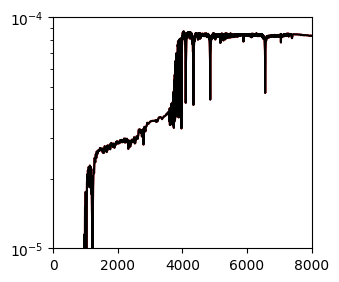

In [4]:
ssp_data = SSPData.load('ssp_data.h5')
csp = CSPBasis(ssp_data)


#Define here the amount of timebins we want to look at. The dimension of the problem goes as <num_time_bins>* 2 (+1, if sigma is included.)
num_time_bins = 3

#Define hyperparamters for rfitting:
rng_key = jax.random.PRNGKey(0)
num_dims = num_time_bins * 2 + 1 #star formation history, metallicity history and sigma
num_live = 1000
num_inner_steps = num_dims * 5
num_delete = num_live // 2



gal_t_table = jnp.linspace(0.1, 13.78, num_time_bins)

# True parameters
true_sfh = jnp.linspace(0.1, 10, num_time_bins)
true_zh = jnp.ones_like(true_sfh) * csp.zlegend[0]

# Create "true" spectrum
csp_true = CSPBasis(ssp_data)
csp_true.add_sfh(sfh=true_sfh, lookback_time=13.8 - gal_t_table)
csp_true.add_zh(zh=true_zh, lookback_time=13.8 - gal_t_table)
spectrum_clean = csp_true.get_spectrum()

# Add noise
key, rng_key = jax.random.split(rng_key)
sigma = 0.003 * jnp.max(spectrum_clean)  # relative noise level
noise = sigma * jax.random.normal(key, shape=spectrum_clean.shape)
spectrum_obs = spectrum_clean #+ noise

# Plot, you can delete this, but I like to plot to check inbetween steps. 
plt.figure(figsize=(10/3, 3))
plt.plot(csp_true.wave, spectrum_obs, label='Observed Spectrum', color='red')
plt.plot(csp_true.wave, csp_true.spectrum, label='CSP Spectrum', color='black')

#plt.errorbar(csp_true.wave, spectrum_obs, yerr=jnp.abs(noise), label='Clean Spectrum', color='blue')
plt.xlim(0, 8000)
plt.yscale('log')
plt.ylim(1e-5, 1e-4) 
plt.show()
plt.close()

# Generate the Model for the Likelihood Function

In [5]:
csp = CSPBasis(ssp_data)

sfh = jnp.ones_like(gal_t_table)  # Initial guess for SFH
zh = jnp.ones_like(gal_t_table) * csp.zlegend[2]
csp.add_sfh(sfh=sfh, lookback_time=13.8 - gal_t_table) #need to set sfh_times 
model = partial(csp.get_spectrum_direct)  # csp is now static

print(model)

lookback time
functools.partial(<bound method CSPBasis.get_spectrum_direct of <CSPBasis Object>
-----------------------------------
Universe Age (tuniv): 13.8 Gyr
Tiny Log Time (tiny_logt): -10
Number of SSP Ages: 108
Number of SSP Metallicities: 12
Wavelength Range: 91.0 - 100000000.0 Å
Star Formation History:
  SFH Times (lookback): [1.3700000e+10 6.8600003e+09 2.0000458e+07]
  SFH Values: [1. 1. 1.]
Spectrum: Not computed yet
>)


# Check Grad and JIT

In [6]:
model = jax.jit(model)
spectrum = model(sfh, zh)

# grad also works (with respect to sfh, for example)
grad_spectrum = grad(lambda sfh: jnp.sum(model(sfh, zh)))(sfh)
print(model)
print('JIT and grad work!')

<PjitFunction of functools.partial(<bound method CSPBasis.get_spectrum_direct of <CSPBasis Object>
-----------------------------------
Universe Age (tuniv): 13.8 Gyr
Tiny Log Time (tiny_logt): -10
Number of SSP Ages: 108
Number of SSP Metallicities: 12
Wavelength Range: 91.0 - 100000000.0 Å
Star Formation History:
  SFH Times (lookback): [1.3700000e+10 6.8600003e+09 2.0000458e+07]
  SFH Values: [1. 1. 1.]
Spectrum: Not computed yet
>)>
JIT and grad work!


# Set Up Likelihood Function

In [7]:

def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = jnp.array(params_flat["sigma"])
    return sfh, zh, sigma

@jit
def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins=num_time_bins)
    mu = model(sfh, zh)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl

# Set up Prior Function


In [8]:
from blackjax.ns.utils import uniform_prior
prior_bounds = {
    'sfh_0': (0.001, 12.0),
    'sfh_1': (0.001, 12.0),
    'sfh_2': (0.001, 12.0),
    'zh_0': (5e-5, 0.02),
    'zh_1': (5e-5, 0.02),
    'zh_2': (5e-5, 0.02),
    'sigma': (1e-7, 1e-5),
}

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = uniform_prior(prior_key, num_live, prior_bounds)


# Test if the likelihood function works

In [9]:
params_test = {'sfh_0': jnp.array([6.89615003, 3]),
    'sfh_1': jnp.array([2.78799016, 4]),
    'sfh_2': jnp.array([2.02322524, 5]),
    'sigma': jnp.array([0.0059143, 0.001]),
    'zh_0': jnp.array([0.00010885, 0.00044]),
    'zh_1': jnp.array([0.0002968, 0.0008]),
    'zh_2': jnp.array([0.0001728, 0.0009])}

lls = jax.vmap(loglikelihood_fn)(params_test)
print(f"Log-likelihoods for test parameters: {lls}")

Log-likelihoods for test parameters: [25243.27 35895.63]


# Nested Sampler ---- What do I have to do different here, Harvey, to implement HMC?

In [10]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
    )

init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)
live = init_fn(particles)

# And this is the part that does not work.

In [ ]:
dead = []
print('Starting sampling...')

with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

print('Sampling completed.')